### Title of Project: Cryptocurrency Time-Series Analysis and Prediction Using Deep Learning

##### Data analyst: Hamed Ahmadinia

##### Data source: Historical cryptocurrency market data collected via public APIs (e.g., Binance, CoinGecko)

##### Computing environment: CSC Puhti supercomputing environment

##### Start of Project: 15.3.2026
##### End of Project: 26.3.2026

###### Email: hamed.ahmadinia@aol.com
###### Web: www.ahmadinia.fi
###### © 2026 Hamed Ahmadinia – CC BY-NC 4.0

### 1. Imports

In [110]:
import gc
import os
import time
import math
import json
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

### 2. Configuration

In [111]:
PROJECT_ROOT = "crypto_project"
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")
LOG_DIR = os.path.join(PROJECT_ROOT, "logs")

for path in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, RESULTS_DIR, CHECKPOINT_DIR, LOG_DIR]:
    os.makedirs(path, exist_ok=True)

SYMBOLS = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "SOLUSDT",
    "XRPUSDT",
    "ADAUSDT",
    "DOGEUSDT",
    "MATICUSDT",
    "DOTUSDT",
    "LTCUSDT"
]

# For first test on Puhti, you may temporarily use:
# SYMBOLS = ["BTCUSDT", "ETHUSDT"]

INTERVAL = "1m"          # "1h", "15m", "5m", "1m"
START_DATE = "2021-01-01"
SEQ_LEN = 48
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
TRAIN_RATIO = 0.8
SLEEP_SECONDS = 0.20

MAX_PROVIDER_RETRIES = 4
MAX_COIN_FAILURES = 20
CHUNK_SAVE_EVERY = 20

### 3. GPU check

In [112]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.9.1+cu129
CUDA available: True
Using device: cuda
GPU: Tesla V100-SXM2-32GB


### 4. Helpers: symbol mapping

In [113]:
def binance_symbol(symbol):
    return symbol

def kucoin_symbol(symbol):
    if symbol.endswith("USDT"):
        return symbol[:-4] + "-USDT"
    return symbol

def coinbase_symbol(symbol):
    # Coinbase often uses USD instead of USDT
    if symbol.endswith("USDT"):
        return symbol[:-4] + "-USD"
    return None

### 5. Logging and checkpoint utils

In [114]:
def checkpoint_path(symbol):
    return os.path.join(CHECKPOINT_DIR, f"{symbol}_{INTERVAL}_checkpoint.json")

def raw_path(symbol):
    return os.path.join(RAW_DIR, f"{symbol}_{INTERVAL}.parquet")

def log_path():
    return os.path.join(LOG_DIR, f"download_log_{INTERVAL}.txt")

def write_log(message):
    ts = pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")
    line = f"[{ts}] {message}"
    print(line)
    with open(log_path(), "a", encoding="utf-8") as f:
        f.write(line + "\n")

def save_checkpoint(symbol, next_start_time, provider_name, rows_downloaded):
    payload = {
        "symbol": symbol,
        "interval": INTERVAL,
        "next_start_time": int(next_start_time) if next_start_time is not None else None,
        "provider_name": provider_name,
        "rows_downloaded": int(rows_downloaded),
        "updated_at": pd.Timestamp.utcnow().isoformat()
    }
    with open(checkpoint_path(symbol), "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)

def load_checkpoint(symbol):
    fp = checkpoint_path(symbol)
    if not os.path.exists(fp):
        return None
    with open(fp, "r", encoding="utf-8") as f:
        return json.load(f)

def get_resume_start_time(symbol):
    cp = load_checkpoint(symbol)
    if cp and cp.get("next_start_time") is not None:
        return int(cp["next_start_time"])
    return int(pd.Timestamp(START_DATE).timestamp() * 1000)

### 6. Standard schema normalizer

In [115]:
STANDARD_COLUMNS = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "number_of_trades",
    "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume",
    "ignore", "symbol", "interval", "provider"
]

def normalize_ohlcv_df(df, symbol, interval, provider_name):
    expected_cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ]

    for col in expected_cols:
        if col not in df.columns:
            df[col] = np.nan

    df = df[expected_cols].copy()

    numeric_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", errors="coerce")
    df["close_time"] = pd.to_datetime(df["close_time"], unit="ms", errors="coerce")
    df["symbol"] = symbol
    df["interval"] = interval
    df["provider"] = provider_name

    return df[STANDARD_COLUMNS]

### 7. Provider 1: Binance

In [116]:
BINANCE_URL = "https://api.binance.com/api/v3/klines"

def fetch_binance(symbol, interval="1m", start_time=None, limit=1000, timeout=60):
    params = {
        "symbol": binance_symbol(symbol),
        "interval": interval,
        "limit": limit
    }
    if start_time is not None:
        params["startTime"] = int(start_time)

    response = requests.get(BINANCE_URL, params=params, timeout=timeout)
    response.raise_for_status()
    data = response.json()

    if not data:
        return pd.DataFrame()

    columns = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ]
    df = pd.DataFrame(data, columns=columns)
    return normalize_ohlcv_df(df, symbol, interval, "binance")

### 8. Provider 2: KuCoin

In [117]:
KUCOIN_URL = "https://api.kucoin.com/api/v1/market/candles"

def kucoin_interval(interval):
    mapping = {
        "1m": "1min",
        "5m": "5min",
        "15m": "15min",
        "1h": "1hour"
    }
    return mapping.get(interval, None)

def interval_millis(interval):
    mapping = {
        "1m": 60_000,
        "5m": 300_000,
        "15m": 900_000,
        "1h": 3_600_000
    }
    return mapping.get(interval, 60_000)

def fetch_kucoin(symbol, interval="1m", start_time=None, limit=1000, timeout=60):
    kc_interval = kucoin_interval(interval)
    kc_symbol = kucoin_symbol(symbol)

    if kc_interval is None or kc_symbol is None:
        return pd.DataFrame()

    params = {
        "type": kc_interval,
        "symbol": kc_symbol
    }

    response = requests.get(KUCOIN_URL, params=params, timeout=timeout)
    response.raise_for_status()
    payload = response.json()

    if "data" not in payload or not payload["data"]:
        return pd.DataFrame()

    rows = payload["data"][:limit]
    rows = list(reversed(rows))

    step_ms = interval_millis(interval)

    parsed = []
    for row in rows:
        # [time, open, close, high, low, volume, turnover]
        ts_sec, open_, close_, high_, low_, volume_, turnover_ = row
        open_ms = int(ts_sec) * 1000
        close_ms = open_ms + step_ms - 1

        parsed.append([
            open_ms, open_, high_, low_, close_, volume_,
            close_ms, turnover_, np.nan, np.nan, np.nan, np.nan
        ])

    df = pd.DataFrame(parsed, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ])

    if start_time is not None:
        df = df[df["open_time"] >= int(start_time)].copy()

    return normalize_ohlcv_df(df, symbol, interval, "kucoin")

### 9. Provider 3: Coinbase

In [118]:
COINBASE_URL_TEMPLATE = "https://api.exchange.coinbase.com/products/{product_id}/candles"

def coinbase_granularity(interval):
    mapping = {
        "1m": 60,
        "5m": 300,
        "15m": 900,
        "1h": 3600
    }
    return mapping.get(interval, None)

def fetch_coinbase(symbol, interval="1m", start_time=None, limit=300, timeout=60):
    product_id = coinbase_symbol(symbol)
    granularity = coinbase_granularity(interval)

    if product_id is None or granularity is None:
        return pd.DataFrame()

    url = COINBASE_URL_TEMPLATE.format(product_id=product_id)
    params = {"granularity": granularity}

    response = requests.get(url, params=params, timeout=timeout)
    response.raise_for_status()
    data = response.json()

    if not data or isinstance(data, dict):
        return pd.DataFrame()

    parsed = []
    for row in data:
        # [time, low, high, open, close, volume]
        ts_sec, low_, high_, open_, close_, volume_ = row
        open_ms = int(ts_sec) * 1000
        close_ms = open_ms + granularity * 1000 - 1
        parsed.append([
            open_ms, open_, high_, low_, close_, volume_,
            close_ms, np.nan, np.nan, np.nan, np.nan, np.nan
        ])

    df = pd.DataFrame(parsed, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume", "ignore"
    ])

    df = df.sort_values("open_time").reset_index(drop=True)

    if start_time is not None:
        df = df[df["open_time"] >= int(start_time)].copy()

    return normalize_ohlcv_df(df, symbol, interval, "coinbase")

### 10. Provider registry

In [119]:
PROVIDERS = [
    ("binance", fetch_binance),
    ("kucoin", fetch_kucoin),
    ("coinbase", fetch_coinbase),
]

### 11. Parquet append/save

In [120]:
def append_and_save(symbol, df_chunk):
    fp = raw_path(symbol)

    if os.path.exists(fp):
        existing = pd.read_parquet(fp)
        combined = pd.concat([existing, df_chunk], ignore_index=True)
        combined = combined.drop_duplicates(subset=["open_time", "symbol"]).sort_values("open_time")
    else:
        combined = df_chunk.drop_duplicates(subset=["open_time", "symbol"]).sort_values("open_time")

    combined.to_parquet(fp, index=False)
    return combined

### 12. Provider rotation fetcher

In [121]:
def fetch_from_any_provider(symbol, interval, start_time, limit=1000):
    provider_errors = []

    for provider_name, provider_fn in PROVIDERS:
        for attempt in range(MAX_PROVIDER_RETRIES):
            try:
                df = provider_fn(
                    symbol=symbol,
                    interval=interval,
                    start_time=start_time,
                    limit=limit
                )

                if df is not None and not df.empty:
                    return df, provider_name

                provider_errors.append(f"{provider_name}: empty response")
                break

            except Exception as e:
                wait = min(2 ** attempt + random.random(), 15)
                provider_errors.append(f"{provider_name} attempt {attempt+1}: {e}")
                write_log(f"{symbol} | provider={provider_name} failed | attempt={attempt+1} | error={e}")
                time.sleep(wait)

    return pd.DataFrame(), provider_errors

### 13. Robust per-coin downloader

In [122]:
def download_coin_robust(symbol, interval="1m", sleep_seconds=0.2, chunk_save_every=20):
    write_log(f"START coin={symbol}")

    start_ts = get_resume_start_time(symbol)
    total_downloaded = 0
    chunk_counter = 0
    failure_counter = 0
    finished = False

    while not finished:
        df_chunk, provider_info = fetch_from_any_provider(
            symbol=symbol,
            interval=interval,
            start_time=start_ts,
            limit=1000
        )

        if df_chunk is None or df_chunk.empty:
            failure_counter += 1
            write_log(f"{symbol} | no usable chunk | failures={failure_counter} | providers={provider_info}")

            if failure_counter >= MAX_COIN_FAILURES:
                write_log(f"{symbol} | STOP after repeated failures")
                break

            time.sleep(5)
            continue

        failure_counter = 0

        df_chunk = df_chunk.dropna(subset=["open_time"]).copy()
        if df_chunk.empty:
            failure_counter += 1
            continue

        last_open_time = int(df_chunk["open_time"].max().timestamp() * 1000)
        next_start = last_open_time + 1

        append_and_save(symbol, df_chunk)

        total_downloaded += len(df_chunk)
        chunk_counter += 1

        provider_used = provider_info
        save_checkpoint(
            symbol=symbol,
            next_start_time=next_start,
            provider_name=provider_used,
            rows_downloaded=total_downloaded
        )

        if chunk_counter % chunk_save_every == 0:
            write_log(f"{symbol} | provider={provider_used} | downloaded_rows={total_downloaded:,}")

        if len(df_chunk) < 1000:
            write_log(f"{symbol} | final partial chunk received | provider={provider_used}")
            finished = True
        else:
            start_ts = next_start
            time.sleep(sleep_seconds)

    fp = raw_path(symbol)
    if os.path.exists(fp):
        final_df = pd.read_parquet(fp).sort_values("open_time").reset_index(drop=True)
        write_log(f"END coin={symbol} | final_rows={len(final_df):,}")
        return final_df

    write_log(f"END coin={symbol} | no file created")
    return pd.DataFrame()

### 14. Download all coins

In [123]:
all_downloaded = []
failed_symbols = []

for symbol in SYMBOLS:
    fp = raw_path(symbol)

    # If file already exists, do not redownload
    if os.path.exists(fp):
        print(f"{symbol}: raw parquet already exists, loading from disk...")
        try:
            df_symbol = pd.read_parquet(fp)
            print(f"{symbol}: loaded {len(df_symbol):,} rows")
            all_downloaded.append(df_symbol)
            continue
        except Exception as e:
            print(f"{symbol}: existing file could not be read, will mark failed | error={e}")
            failed_symbols.append(symbol)
            continue

    # Only download if file does not exist
    try:
        print(f"{symbol}: not found on disk, downloading...")
        df_symbol = download_coin_robust(
            symbol=symbol,
            interval=INTERVAL,
            sleep_seconds=SLEEP_SECONDS,
            chunk_save_every=CHUNK_SAVE_EVERY
        )

        if df_symbol.empty:
            failed_symbols.append(symbol)
            print(f"{symbol}: download returned empty")
            continue

        all_downloaded.append(df_symbol)
        print(f"{symbol}: completed successfully")

    except Exception as e:
        failed_symbols.append(symbol)
        print(f"{symbol}: crashed unexpectedly | error={e}")
        continue

if all_downloaded:
    df_all = pd.concat(all_downloaded, ignore_index=True)
    df_all = df_all.drop_duplicates(subset=["open_time", "symbol"]).sort_values(["symbol", "open_time"])
    print("Combined shape:", df_all.shape)
else:
    df_all = pd.DataFrame()
    print("No successful downloads.")

print("Failed symbols:", failed_symbols)

BTCUSDT: raw parquet already exists, loading from disk...
BTCUSDT: loaded 2,749,792 rows
ETHUSDT: raw parquet already exists, loading from disk...
ETHUSDT: loaded 2,749,792 rows
BNBUSDT: raw parquet already exists, loading from disk...
BNBUSDT: loaded 2,749,792 rows
SOLUSDT: raw parquet already exists, loading from disk...
SOLUSDT: loaded 2,749,793 rows
XRPUSDT: raw parquet already exists, loading from disk...
XRPUSDT: loaded 2,749,794 rows
ADAUSDT: raw parquet already exists, loading from disk...
ADAUSDT: loaded 2,749,793 rows
DOGEUSDT: raw parquet already exists, loading from disk...
DOGEUSDT: loaded 2,749,793 rows
MATICUSDT: raw parquet already exists, loading from disk...
MATICUSDT: loaded 1,940,578 rows
DOTUSDT: raw parquet already exists, loading from disk...
DOTUSDT: loaded 2,749,768 rows
LTCUSDT: raw parquet already exists, loading from disk...
LTCUSDT: loaded 2,749,769 rows
Combined shape: (26688664, 15)
Failed symbols: []


### 15. Dataset size check & fast-train setup

In [124]:
raw_files = [raw_path(symbol) for symbol in SYMBOLS if os.path.exists(raw_path(symbol))]
total_size_bytes = sum(os.path.getsize(fp) for fp in raw_files)

# Parquet (compressed)
total_size_gb = total_size_bytes / (1024 ** 3)
print(f"Approx raw parquet size: {total_size_gb:.3f} GB")

# CSV estimate (uncompressed)
total_size_csv_estimate = total_size_bytes * 3
print(f"Estimated CSV size: {total_size_csv_estimate / (1024**3):.2f} GB")

TRAIN_SYMBOLS = ["BTCUSDT", "ETHUSDT", "BNBUSDT"]   # only these 3 coins for model training
EXPORT_SYMBOLS = [symbol for symbol in SYMBOLS if os.path.exists(raw_path(symbol))]  # all downloaded coins for section 33

MAX_ROWS_PER_TRAIN_COIN = None
EPOCHS = 5                      
BATCH_SIZE = 64

print("Training coins:", TRAIN_SYMBOLS)
print("Export coins:", EXPORT_SYMBOLS)
print("MAX_ROWS_PER_TRAIN_COIN:", MAX_ROWS_PER_TRAIN_COIN)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)

Approx raw parquet size: 1.382 GB
Estimated CSV size: 4.15 GB
Training coins: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT']
Export coins: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'MATICUSDT', 'DOTUSDT', 'LTCUSDT']
MAX_ROWS_PER_TRAIN_COIN: None
EPOCHS: 5
BATCH_SIZE: 64


### 16. Feature engineering

In [125]:
def add_features(df_symbol):
    df_symbol = df_symbol.sort_values("open_time").copy()
    df_symbol["return_1"] = df_symbol["close"].pct_change()
    df_symbol["log_return_1"] = np.log(df_symbol["close"] / df_symbol["close"].shift(1))
    df_symbol["ma_24"] = df_symbol["close"].rolling(24).mean()
    df_symbol["std_24"] = df_symbol["close"].rolling(24).std()
    df_symbol["ma_72"] = df_symbol["close"].rolling(72).mean()
    df_symbol["std_72"] = df_symbol["close"].rolling(72).std()
    df_symbol["ma_168"] = df_symbol["close"].rolling(168).mean()
    df_symbol["std_168"] = df_symbol["close"].rolling(168).std()
    df_symbol["volume_ma_24"] = df_symbol["volume"].rolling(24).mean()
    df_symbol = df_symbol.dropna().reset_index(drop=True)
    return df_symbol

feature_dfs = []

for symbol in TRAIN_SYMBOLS:
    fp = raw_path(symbol)

    if not os.path.exists(fp):
        print(f"Missing raw file for {symbol}, skipping.")
        continue

    coin_df = pd.read_parquet(fp)

    if coin_df.empty:
        print(f"Empty raw file for {symbol}, skipping.")
        continue

    coin_df = add_features(coin_df)

    if coin_df.empty:
        print(f"No usable data after feature engineering for {symbol}, skipping.")
        continue

    # Use all rows when MAX_ROWS_PER_TRAIN_COIN is None
    if MAX_ROWS_PER_TRAIN_COIN is not None:
        coin_df = coin_df.tail(MAX_ROWS_PER_TRAIN_COIN).reset_index(drop=True)

    feature_dfs.append(coin_df)
    print(f"{symbol}: feature rows kept = {len(coin_df):,}")

if len(feature_dfs) == 0:
    raise ValueError("No usable feature data was produced.")

df_features = pd.concat(feature_dfs, ignore_index=True)
df_features = df_features.sort_values(["symbol", "open_time"]).reset_index(drop=True)

processed_path = os.path.join(
    PROCESSED_DIR,
    f"train_subset_features_{INTERVAL}_{len(TRAIN_SYMBOLS)}coins.parquet"
)
df_features.to_parquet(processed_path, index=False)

print("Saved processed features:", processed_path)
print("Processed shape:", df_features.shape)
print(df_features["symbol"].value_counts())
print(df_features.head())

BTCUSDT: feature rows kept = 2,749,625
ETHUSDT: feature rows kept = 2,749,625
BNBUSDT: feature rows kept = 2,749,625
Saved processed features: crypto_project/data/processed/train_subset_features_1m_3coins.parquet
Processed shape: (8248875, 24)
symbol
BNBUSDT    2749625
BTCUSDT    2749625
ETHUSDT    2749625
Name: count, dtype: int64
            open_time     open     high      low    close    volume  \
0 2021-01-01 02:47:00  37.7519  37.7645  37.7236  37.7401   688.981   
1 2021-01-01 02:48:00  37.7401  37.7543  37.7245  37.7339  1068.020   
2 2021-01-01 02:49:00  37.7339  37.7452  37.7183  37.7185  1718.877   
3 2021-01-01 02:50:00  37.7202  37.7734  37.7115  37.7663  3597.829   
4 2021-01-01 02:51:00  37.7643  37.7750  37.7349  37.7351  1855.683   

               close_time  quote_asset_volume  number_of_trades  \
0 2021-01-01 02:47:59.999        26003.925956                84   
1 2021-01-01 02:48:59.999        40304.415068                82   
2 2021-01-01 02:49:59.999        64851

### 17. Feature selection

In [126]:
feature_cols = [
    "open", "high", "low", "close", "volume", "number_of_trades",
    "quote_asset_volume", "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume",
    "return_1", "log_return_1",
    "ma_24", "std_24",
    "ma_72", "std_72",
    "ma_168", "std_168",
    "volume_ma_24"
]

target_col = "close"
target_index = feature_cols.index(target_col)

### 18. Prepare per-coin scaled arrays and metadata

In [127]:
coin_data_store = {}
scalers = {}
usable_symbols = []

for symbol in sorted(df_features["symbol"].unique()):
    print(f"Preparing {symbol} ...")

    coin_df = df_features[df_features["symbol"] == symbol].copy()
    coin_data = coin_df[feature_cols].copy()

    if len(coin_data) < SEQ_LEN + 20:
        print(f"Skipping {symbol}: not enough rows.")
        continue

    train_size = int(len(coin_data) * TRAIN_RATIO)
    train_df = coin_data.iloc[:train_size].copy()
    test_df = coin_data.iloc[train_size:].copy()

    if len(train_df) < SEQ_LEN + 1 or len(test_df) < SEQ_LEN + 1:
        print(f"Skipping {symbol}: train/test split too small.")
        continue

    scaler = MinMaxScaler()

    # IMPORTANT: cast to float32 to reduce memory
    train_scaled = scaler.fit_transform(train_df).astype(np.float32)
    test_scaled = scaler.transform(test_df).astype(np.float32)

    scalers[symbol] = scaler
    usable_symbols.append(symbol)

    coin_data_store[symbol] = {
        "train_scaled": train_scaled,
        "test_scaled": test_scaled,
        "train_len": len(train_scaled),
        "test_len": len(test_scaled),
    }

    print(
        f"{symbol} | train rows={len(train_scaled):,} | "
        f"test rows={len(test_scaled):,}"
    )

    del coin_df, coin_data, train_df, test_df
    gc.collect()

print("\nUsable symbols:", usable_symbols)
print("Total usable symbols:", len(usable_symbols))

Preparing BNBUSDT ...
BNBUSDT | train rows=2,199,700 | test rows=549,925
Preparing BTCUSDT ...
BTCUSDT | train rows=2,199,700 | test rows=549,925
Preparing ETHUSDT ...
ETHUSDT | train rows=2,199,700 | test rows=549,925

Usable symbols: ['BNBUSDT', 'BTCUSDT', 'ETHUSDT']
Total usable symbols: 3


### 19. Dataset with labels

In [128]:
class LazyMultiCoinSequenceDataset(Dataset):
    def __init__(self, coin_data_store, symbols, split="train", seq_len=48, target_index=0):
        self.coin_data_store = coin_data_store
        self.symbols = symbols
        self.split = split
        self.seq_len = seq_len
        self.target_index = target_index

        self.index_map = []   # list of (symbol, end_idx)
        self.symbol_to_id = {symbol: i for i, symbol in enumerate(symbols)}
        self.id_to_symbol = {i: symbol for symbol, i in self.symbol_to_id.items()}

        for symbol in self.symbols:
            arr = self.coin_data_store[symbol][f"{split}_scaled"]
            n = len(arr)
            if n > self.seq_len:
                # sample i uses arr[i-seq_len:i], target arr[i, target_index]
                for end_idx in range(self.seq_len, n):
                    self.index_map.append((symbol, end_idx))

        print(f"{split} dataset size: {len(self.index_map):,}")

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        symbol, end_idx = self.index_map[idx]
        arr = self.coin_data_store[symbol][f"{self.split}_scaled"]

        x = arr[end_idx - self.seq_len:end_idx]
        y = arr[end_idx, self.target_index]
        symbol_id = self.symbol_to_id[symbol]

        return (
            torch.from_numpy(x),                                   # shape: (seq_len, n_features)
            torch.tensor([y], dtype=torch.float32),               # shape: (1,)
            torch.tensor(symbol_id, dtype=torch.long)             # scalar
        )

### 20. DataLoaders

In [129]:
train_dataset = LazyMultiCoinSequenceDataset(
    coin_data_store=coin_data_store,
    symbols=usable_symbols,
    split="train",
    seq_len=SEQ_LEN,
    target_index=target_index
)

test_dataset = LazyMultiCoinSequenceDataset(
    coin_data_store=coin_data_store,
    symbols=usable_symbols,
    split="test",
    seq_len=SEQ_LEN,
    target_index=target_index
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

train dataset size: 6,598,956
test dataset size: 1,649,631


### 21. LSTM model

In [130]:
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

### 22. Transformer model

In [131]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

class TransformerRegressor(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x

### 23. Training and evaluation helpers

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def train_model(model, train_loader, criterion, optimizer, device, epochs=10):
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch, _symbol_ids in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.6f}")

    return history


def evaluate_model_with_labels(model, data_loader, device):
    model.eval()

    preds_list = []
    true_list = []
    symbol_ids_list = []

    with torch.no_grad():
        for X_batch, y_batch, symbol_ids in data_loader:
            X_batch = X_batch.to(device, non_blocking=True)

            preds = model(X_batch).cpu().numpy().flatten()
            y_true = y_batch.numpy().flatten()
            symbol_ids_np = symbol_ids.numpy().flatten()

            preds_list.append(preds)
            true_list.append(y_true)
            symbol_ids_list.append(symbol_ids_np)

    preds_arr = np.concatenate(preds_list)
    true_arr = np.concatenate(true_list)
    symbol_ids_arr = np.concatenate(symbol_ids_list)

    mae = mean_absolute_error(true_arr, preds_arr)
    rmse = math.sqrt(mean_squared_error(true_arr, preds_arr))

    return preds_arr, true_arr, symbol_ids_arr, mae, rmse


def inverse_transform_target_per_coin(scaled_values, scaler, target_index, n_features):
    dummy = np.zeros((len(scaled_values), n_features), dtype=np.float32)
    dummy[:, target_index] = scaled_values
    restored = scaler.inverse_transform(dummy)
    return restored[:, target_index]

### 24. Train LSTM

In [133]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

lstm_model = LSTMRegressor(input_size=len(feature_cols)).to(device)
criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LEARNING_RATE)

print("\nTraining LSTM...")
lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=lstm_optimizer,
    device=device,
    epochs=EPOCHS
)

lstm_preds, y_true, test_symbol_ids, lstm_mae, lstm_rmse = evaluate_model_with_labels(
    lstm_model, test_loader, device
)

print("LSTM scaled MAE:", lstm_mae)
print("LSTM scaled RMSE:", lstm_rmse)

Using device: cuda

Training LSTM...
Epoch 1/5 | Loss: 0.000034
Epoch 2/5 | Loss: 0.000002
Epoch 3/5 | Loss: 0.000002
Epoch 4/5 | Loss: 0.000001
Epoch 5/5 | Loss: 0.000001
LSTM scaled MAE: 0.054752934724092484
LSTM scaled RMSE: 0.10684565407539444


### 25. Train Transformer

In [134]:
transformer_model = TransformerRegressor(
    input_size=len(feature_cols),
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1
).to(device)

criterion = nn.MSELoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=LEARNING_RATE)

print("\nTraining Transformer...")
transformer_history = train_model(
    model=transformer_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=transformer_optimizer,
    device=device,
    epochs=EPOCHS
)

transformer_preds, y_true_2, test_symbol_ids_2, transformer_mae, transformer_rmse = evaluate_model_with_labels(
    transformer_model, test_loader, device
)

print("Transformer scaled MAE:", transformer_mae)
print("Transformer scaled RMSE:", transformer_rmse)


Training Transformer...
Epoch 1/5 | Loss: 0.000025
Epoch 2/5 | Loss: 0.000001
Epoch 3/5 | Loss: 0.000001
Epoch 4/5 | Loss: 0.000001
Epoch 5/5 | Loss: 0.000001
Transformer scaled MAE: 0.014998873695731163
Transformer scaled RMSE: 0.043155003693164405


### 26. Baseline (Naive previous value)

In [135]:
baseline_preds = []

for symbol_id in sorted(np.unique(test_symbol_ids)):
    mask = (test_symbol_ids == symbol_id)
    y_coin = y_true[mask]

    # naive prediction: previous value
    baseline = np.roll(y_coin, 1)
    baseline[0] = y_coin[0]

    baseline_preds.append(baseline)

baseline_preds = np.concatenate(baseline_preds)

baseline_mae = mean_absolute_error(y_true, baseline_preds)
baseline_rmse = math.sqrt(mean_squared_error(y_true, baseline_preds))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 0.00043381197610870004
Baseline RMSE: 0.0007442227449432122


### 27. Overall comparison

In [148]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "LSTM", "Transformer"],
    "Scaled_MAE": [baseline_mae, lstm_mae, transformer_mae],
    "Scaled_RMSE": [baseline_rmse, lstm_rmse, transformer_rmse]
})

print("\nOverall comparison:")
display(comparison_df)


Overall comparison:


,Model,Scaled_MAE,Scaled_RMSE
0,Baseline,0.000434,0.000744
1,LSTM,0.054753,0.106846
2,Transformer,0.014999,0.043155


### 28. Per-coin evaluation (scaled)

In [149]:
per_coin_results = []

id_to_symbol = test_dataset.id_to_symbol

for symbol_id in sorted(np.unique(test_symbol_ids)):
    symbol = id_to_symbol[int(symbol_id)]
    mask = (test_symbol_ids == symbol_id)

    y_coin = y_true[mask]
    lstm_coin = lstm_preds[mask]
    transformer_coin = transformer_preds[mask]

    lstm_mae_coin = mean_absolute_error(y_coin, lstm_coin)
    lstm_rmse_coin = math.sqrt(mean_squared_error(y_coin, lstm_coin))

    transformer_mae_coin = mean_absolute_error(y_coin, transformer_coin)
    transformer_rmse_coin = math.sqrt(mean_squared_error(y_coin, transformer_coin))

    better_model = "LSTM" if lstm_rmse_coin < transformer_rmse_coin else "Transformer"

    per_coin_results.append({
        "Coin": symbol.replace("USDT", ""),
        "Num_Test_Samples": int(mask.sum()),
        "LSTM_MAE": lstm_mae_coin,
        "LSTM_RMSE": lstm_rmse_coin,
        "Transformer_MAE": transformer_mae_coin,
        "Transformer_RMSE": transformer_rmse_coin,
        "Better_Model_By_RMSE": better_model
    })

per_coin_df = pd.DataFrame(per_coin_results).sort_values("Coin").reset_index(drop=True)

print("\nPer-coin comparison (scaled):")
display(per_coin_df.round(6))


Per-coin comparison (scaled):


,Coin,Num_Test_Samples,LSTM_MAE,LSTM_RMSE,Transformer_MAE,Transformer_RMSE,Better_Model_By_RMSE
0,BNB,549877,0.081944,0.167294,0.037957,0.073224,Transformer
1,BTC,549877,0.019471,0.031133,0.006477,0.014984,Transformer
2,ETH,549877,0.062843,0.072742,0.000563,0.000857,Transformer


### 29. Best model per coin (scaled RMSE)

In [150]:
per_coin_df["Best_Model"] = np.where(
    per_coin_df["LSTM_RMSE"] < per_coin_df["Transformer_RMSE"],
    "LSTM",
    "Transformer"
)

print("\nBest model per coin:")
print(per_coin_df["Best_Model"].value_counts())


Best model per coin:
Best_Model
Transformer    3
Name: count, dtype: int64


### 30. Per-coin evaluation (original scale)

In [151]:
per_coin_original_results = []

for symbol_id in sorted(np.unique(test_symbol_ids)):
    symbol = id_to_symbol[int(symbol_id)]
    mask = (test_symbol_ids == symbol_id)

    y_coin_scaled = y_true[mask]
    lstm_coin_scaled = lstm_preds[mask]
    transformer_coin_scaled = transformer_preds[mask]

    scaler = scalers[symbol]

    y_coin_orig = inverse_transform_target_per_coin(
        y_coin_scaled, scaler, target_index, len(feature_cols)
    )
    lstm_coin_orig = inverse_transform_target_per_coin(
        lstm_coin_scaled, scaler, target_index, len(feature_cols)
    )
    transformer_coin_orig = inverse_transform_target_per_coin(
        transformer_coin_scaled, scaler, target_index, len(feature_cols)
    )

    lstm_mae_orig = mean_absolute_error(y_coin_orig, lstm_coin_orig)
    lstm_rmse_orig = math.sqrt(mean_squared_error(y_coin_orig, lstm_coin_orig))

    transformer_mae_orig = mean_absolute_error(y_coin_orig, transformer_coin_orig)
    transformer_rmse_orig = math.sqrt(mean_squared_error(y_coin_orig, transformer_coin_orig))

    better_model = "LSTM" if lstm_rmse_orig < transformer_rmse_orig else "Transformer"

    per_coin_original_results.append({
        "Coin": symbol.replace("USDT", ""),
        "LSTM_MAE_Original": lstm_mae_orig,
        "LSTM_RMSE_Original": lstm_rmse_orig,
        "Transformer_MAE_Original": transformer_mae_orig,
        "Transformer_RMSE_Original": transformer_rmse_orig,
        "Better_Model_By_Original_RMSE": better_model
    })

per_coin_original_df = pd.DataFrame(per_coin_original_results).sort_values("Coin").reset_index(drop=True)

print("\nPer-coin comparison (original price scale):")
display(per_coin_original_df.round(4))


Per-coin comparison (original price scale):


,Coin,LSTM_MAE_Original,LSTM_RMSE_Original,Transformer_MAE_Original,Transformer_RMSE_Original,Better_Model_By_Original_RMSE
0,BNB,62.1274,126.8368,28.7775,55.5162,Transformer
1,BTC,1824.0626,2916.5492,606.7809,1403.7213,Transformer
2,ETH,260.7999,301.8777,2.3354,3.5581,Transformer


### 31. Save outputs

In [152]:
torch.save(lstm_model.state_dict(), os.path.join(MODEL_DIR, f"lstm_multi_coin_{INTERVAL}.pt"))
torch.save(transformer_model.state_dict(), os.path.join(MODEL_DIR, f"transformer_multi_coin_{INTERVAL}.pt"))

comparison_df.to_csv(os.path.join(RESULTS_DIR, f"model_comparison_{INTERVAL}.csv"), index=False)
per_coin_df.to_csv(os.path.join(RESULTS_DIR, f"per_coin_model_comparison_scaled_{INTERVAL}.csv"), index=False)
per_coin_original_df.to_csv(os.path.join(RESULTS_DIR, f"per_coin_model_comparison_original_{INTERVAL}.csv"), index=False)

print("Saved models and result tables.")

Saved models and result tables.


### 32. Plot training loss

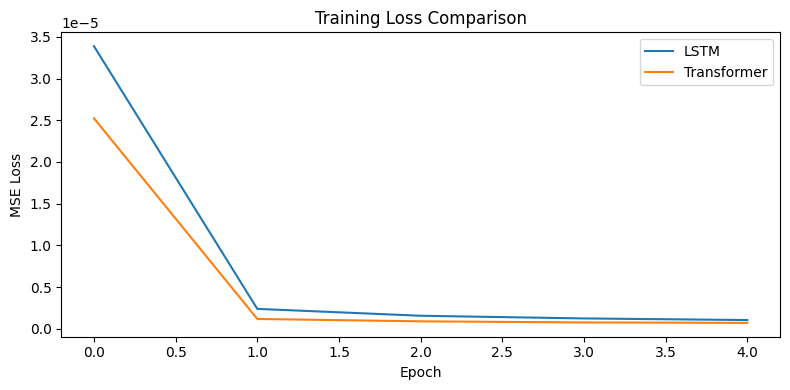

In [153]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_history, label="LSTM")
plt.plot(transformer_history, label="Transformer")
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

### 33. Plot overall predictions

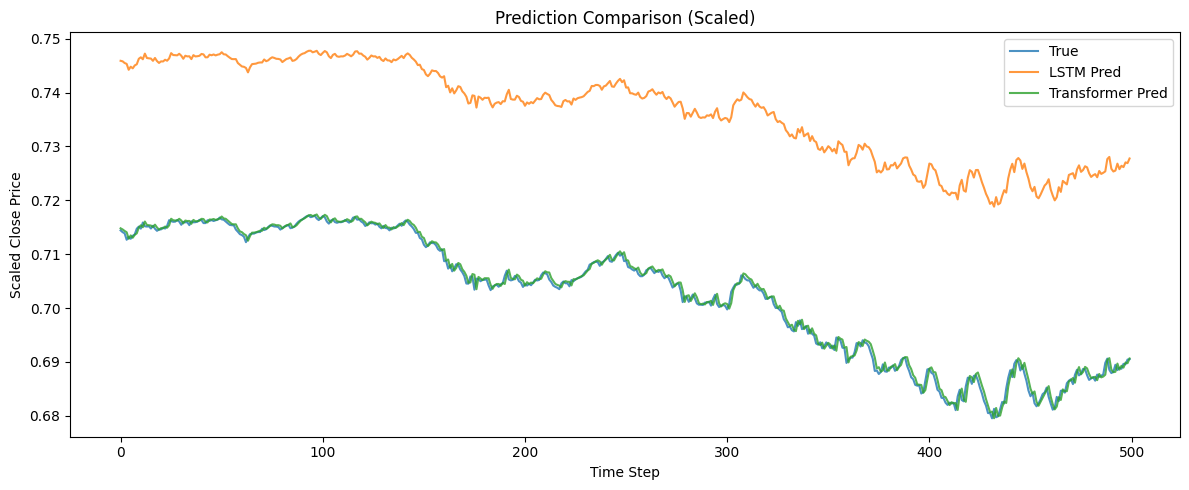

In [154]:
sample_n = min(500, len(y_true))

plt.figure(figsize=(12, 5))
plt.plot(y_true[:sample_n], label="True", alpha=0.8)
plt.plot(lstm_preds[:sample_n], label="LSTM Pred", alpha=0.8)
plt.plot(transformer_preds[:sample_n], label="Transformer Pred", alpha=0.8)
plt.title("Prediction Comparison (Scaled)")
plt.xlabel("Time Step")
plt.ylabel("Scaled Close Price")
plt.legend()
plt.tight_layout()
plt.show()

### 34. Multi-coin prediction visualization

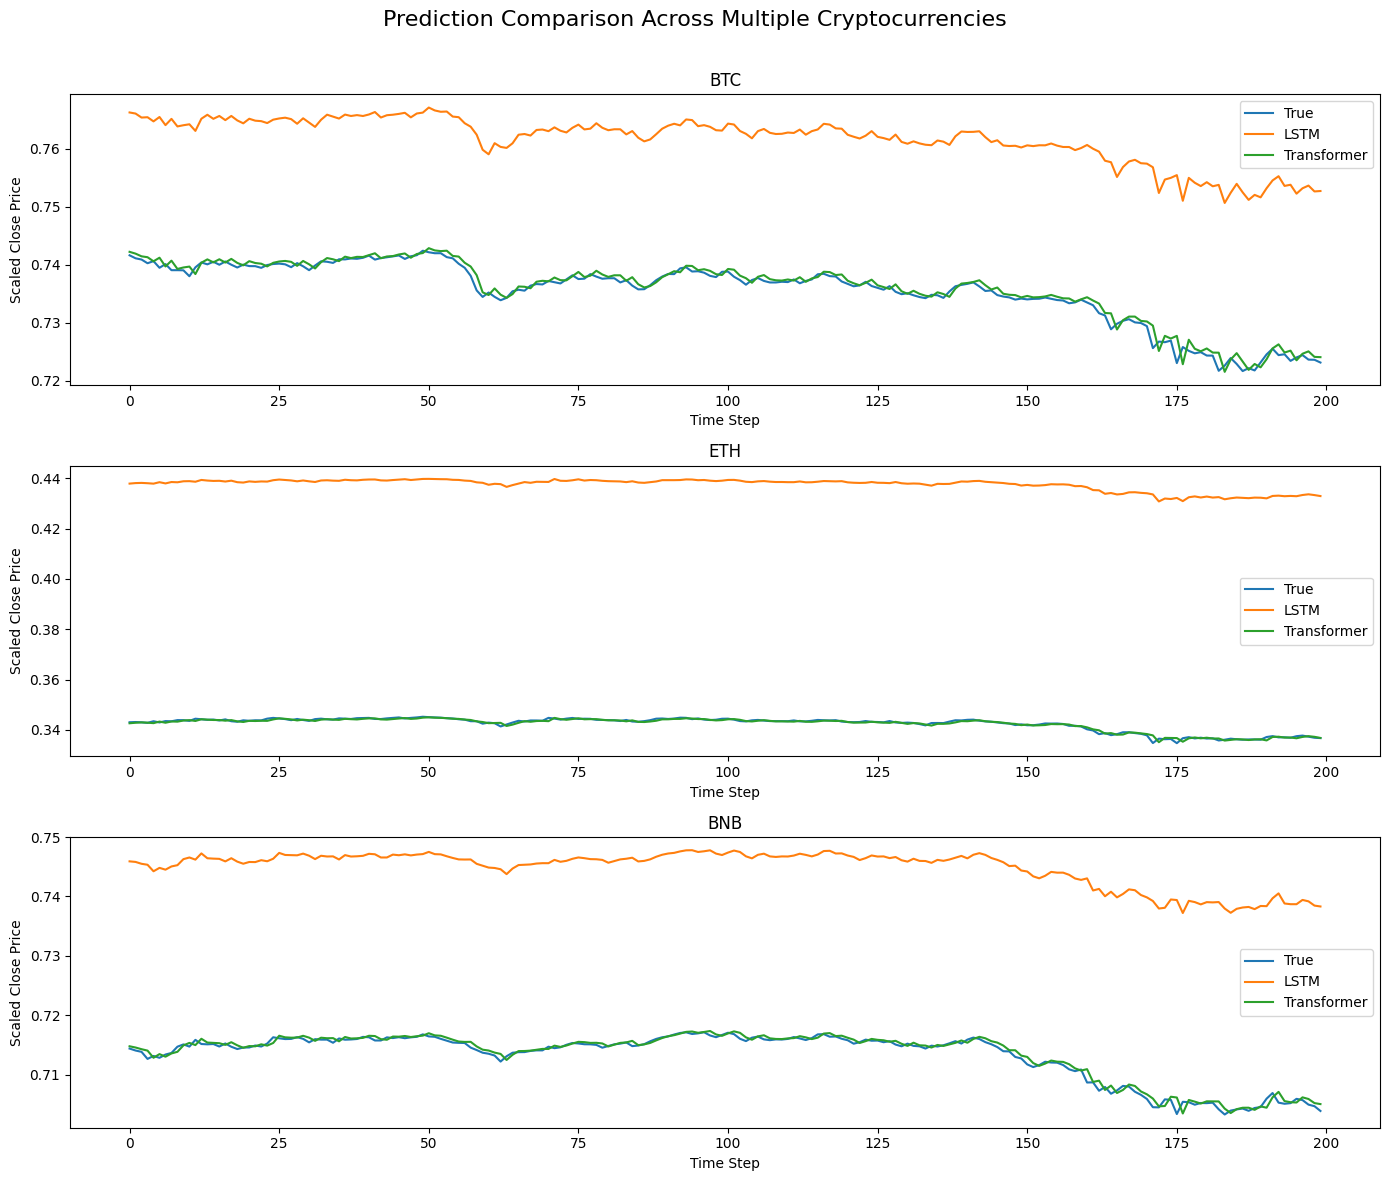

In [156]:
import matplotlib.pyplot as plt
import numpy as np

id_to_symbol = test_dataset.id_to_symbol
symbol_to_id = {v: k for k, v in id_to_symbol.items()}

selected_symbols = ["BTCUSDT", "ETHUSDT", "BNBUSDT"]

fig, axes = plt.subplots(len(selected_symbols), 1, figsize=(14, 12), sharex=False)
fig.suptitle("Prediction Comparison Across Multiple Cryptocurrencies", fontsize=16)

if len(selected_symbols) == 1:
    axes = [axes]

for ax, symbol in zip(axes, selected_symbols):
    if symbol not in symbol_to_id:
        ax.set_title(f"{symbol} not available in test set")
        ax.axis("off")
        continue

    symbol_id = symbol_to_id[symbol]
    coin_mask = (test_symbol_ids == symbol_id)

    y_coin = y_true[coin_mask]
    lstm_coin = lstm_preds[coin_mask]
    transformer_coin = transformer_preds[coin_mask]

    n = min(200, len(y_coin))

    ax.plot(y_coin[:n], label="True")
    ax.plot(lstm_coin[:n], label="LSTM")
    ax.plot(transformer_coin[:n], label="Transformer")

    ax.set_title(f"{symbol.replace('USDT', '')}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Scaled Close Price")
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 35. Plot per-coin RMSE and report tables

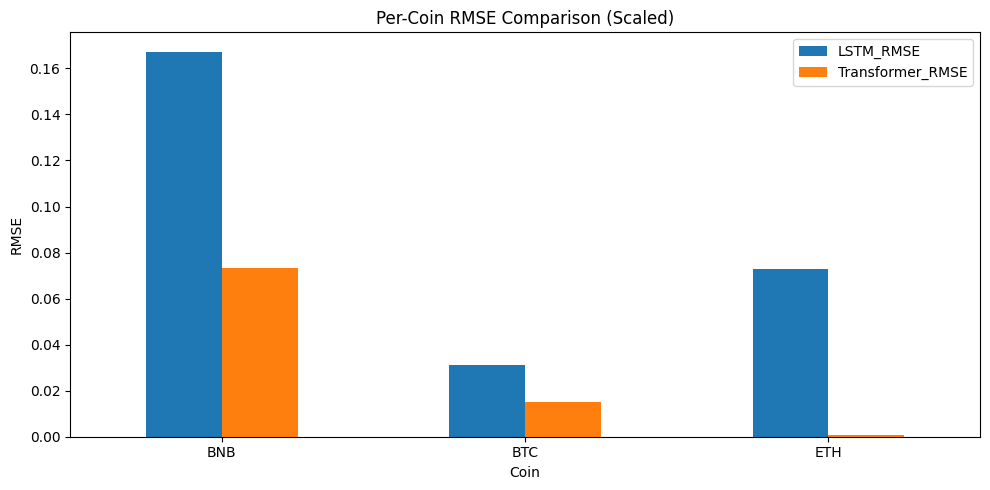


Report table (scaled):


,Coin,Num_Test_Samples,LSTM_MAE,LSTM_RMSE,Transformer_MAE,Transformer_RMSE,Better_Model_By_RMSE,Best_Model
0,BNB,549877,0.081944,0.167294,0.037957,0.073224,Transformer,Transformer
1,BTC,549877,0.019471,0.031133,0.006477,0.014984,Transformer,Transformer
2,ETH,549877,0.062843,0.072742,0.000563,0.000857,Transformer,Transformer



Report table (original scale):


,Coin,LSTM_MAE_Original,LSTM_RMSE_Original,Transformer_MAE_Original,Transformer_RMSE_Original,Better_Model_By_Original_RMSE
0,BNB,62.1274,126.8368,28.7775,55.5162,Transformer
1,BTC,1824.0626,2916.5492,606.7809,1403.7213,Transformer
2,ETH,260.7999,301.8777,2.3354,3.5581,Transformer


In [157]:
plot_df = per_coin_df.set_index("Coin")[["LSTM_RMSE", "Transformer_RMSE"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Per-Coin RMSE Comparison (Scaled)")
plt.ylabel("RMSE")
plt.xlabel("Coin")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

report_table_scaled = per_coin_df.copy()
for col in ["LSTM_MAE", "LSTM_RMSE", "Transformer_MAE", "Transformer_RMSE"]:
    report_table_scaled[col] = report_table_scaled[col].round(6)

report_table_original = per_coin_original_df.copy()
for col in ["LSTM_MAE_Original", "LSTM_RMSE_Original", "Transformer_MAE_Original", "Transformer_RMSE_Original"]:
    report_table_original[col] = report_table_original[col].round(4)

print("\nReport table (scaled):")
display(report_table_scaled)

print("\nReport table (original scale):")
display(report_table_original)

### 36. Create downloadable CSV file from dataset

In [158]:
csv_output_path = os.path.join(RESULTS_DIR, f"crypto_dataset_{INTERVAL}_ALL_COINS.csv")

if os.path.exists(csv_output_path):
    print(f"CSV already exists at: {csv_output_path}")
    print("Skipping export to avoid overwriting.")
else:
    first_write = True
    rows_written = 0

    with open(csv_output_path, "w", encoding="utf-8", newline="") as f:
        for symbol in EXPORT_SYMBOLS:
            print(f"Exporting {symbol} to CSV...")

            symbol_dir = os.path.join(RAW_DIR, f"{symbol}_{INTERVAL}")
            single_file = os.path.join(RAW_DIR, f"{symbol}_{INTERVAL}.parquet")

            if os.path.isdir(symbol_dir):
                chunk_files = sorted([
                    os.path.join(symbol_dir, file_name)
                    for file_name in os.listdir(symbol_dir)
                    if file_name.endswith(".parquet")
                ])

                for fp in chunk_files:
                    chunk_df = pd.read_parquet(fp)
                    chunk_df.to_csv(f, index=False, header=first_write)
                    rows_written += len(chunk_df)
                    first_write = False
                    del chunk_df

            elif os.path.exists(single_file):
                chunk_df = pd.read_parquet(single_file)
                chunk_df.to_csv(f, index=False, header=first_write)
                rows_written += len(chunk_df)
                first_write = False
                del chunk_df

            else:
                print(f"Skipped {symbol}: no raw parquet found.")

            gc.collect()

    print(f"CSV export completed: {csv_output_path}")
    print(f"Total rows written: {rows_written:,}")

CSV already exists at: crypto_project/results/crypto_dataset_1m_ALL_COINS.csv
Skipping export to avoid overwriting.
